In [5]:
from PIL import Image
import numpy as np
import os
import random
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

In [15]:
train_dir = "/content/drive/MyDrive/AI and ML/Week-5/FruitinAmazon/train"
test_dir = "/content/drive/MyDrive/AI and ML/Week-5/FruitinAmazon/test"

In [7]:
classes = [cls for cls in os.listdir(train_dir)
           if os.path.isdir(os.path.join(train_dir, cls))]

print("Classes:", classes)

Classes: ['acai', 'tucuma', 'pupunha', 'cupuacu', 'guarana', 'graviola']


In [8]:
images = []
labels = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)


    img_files = [f for f in os.listdir(class_path)
                 if os.path.isfile(os.path.join(class_path, f))]

    if len(img_files) == 0:
        continue

    img_name = random.choice(img_files)
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)
    images.append(img)
    labels.append(cls)

In [9]:
num_images = len(images)
cols = (num_images + 1) // 2

In [10]:
plt.figure(figsize=(15, 6))

<Figure size 1500x600 with 0 Axes>

<Figure size 1500x600 with 0 Axes>

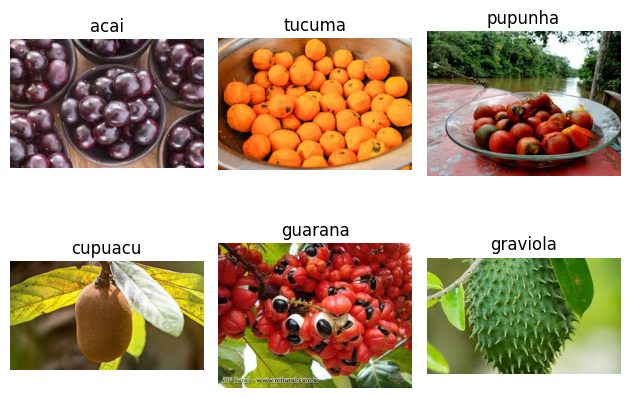

In [11]:
for i in range(num_images):
    plt.subplot(2, cols, i + 1)
    plt.imshow(images[i])
    plt.title(labels[i])
    plt.axis('off')

plt.tight_layout()
plt.show()

In [16]:
corrupted_images = []

for cls in classes:
    class_path = os.path.join(train_dir, cls)

    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)

        if not os.path.isfile(img_path):
            continue

        try:
            with Image.open(img_path) as img:
                img.verify()   # verifies image integrity

        except (IOError, SyntaxError):
            corrupted_images.append(img_path)
            os.remove(img_path)
            print(f"Removed corrupted image: {img_path}")

In [17]:
if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")
else:
    print("\nTotal corrupted images removed:", len(corrupted_images))

No Corrupted Images Found.


In [32]:
import tensorflow as tf
# Define image size and batch size
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]
# Create training dataset with normalization
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=True,
validation_split=validation_split,
subset='training',
seed=123
)
# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))
# Create validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
train_dir,
labels='inferred',
label_mode='int',
image_size=(img_height, img_width),
interpolation='nearest',
batch_size=batch_size,
shuffle=False,
validation_split=validation_split,
subset='validation',
seed=123
)
# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([

    # 🔹 Conv Block 1
    Conv2D(32, (3, 3), padding='same', strides=1,
           input_shape=(128, 128, 3)),
    tf.keras.layers.ReLU(),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    # 🔹 Conv Block 2
    Conv2D(32, (3, 3), padding='same', strides=1),
    tf.keras.layers.ReLU(),
    MaxPooling2D(pool_size=(2, 2), strides=2),

    # 🔹 Fully Connected Layers
    Flatten(),
    Dense(64, activation='relu'),
    Dense(128, activation='relu'),

    # 🔹 Output Layer
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,970 (8.08 MB)

 Trainable params: 2,116,970 (8.08 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [23]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Callbacks
checkpoint = ModelCheckpoint(
    "best_model.h5",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.0735 - loss: 2.6296
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.1111 - loss: 2.6834 - val_accuracy: 0.0000e+00 - val_loss: 1.8023
Epoch 2/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.1997 - loss: 1.9097
Epoch 2: val_accuracy improved from 0.00000 to 0.22222, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 679ms/step - accuracy: 0.2083 - loss: 1.8789 - val_accuracy: 0.2222 - val_loss: 1.7336
Epoch 3/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 371ms/step - accuracy: 0.1985 - loss: 1.6953
Epoch 3: val_accuracy improved from 0.22222 to 0.55556, saving model to best_model.h5



Epoch 3: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 525ms/step - accuracy: 0.2361 - loss: 1.6704 - val_accuracy: 0.5556 - val_loss: 1.6438
Epoch 4/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.3432 - loss: 1.4902
Epoch 4: val_accuracy did not improve from 0.55556
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 530ms/step - accuracy: 0.3889 - loss: 1.4634 - val_accuracy: 0.2778 - val_loss: 1.5971
Epoch 5/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 476ms/step - accuracy: 0.4896 - loss: 1.2742
Epoch 5: val_accuracy did not improve from 0.55556
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 648ms/step - accuracy: 0.5000 - loss: 1.2606 - val_accuracy: 0.5556 - val_loss: 1.2198
Epoch 6/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 620ms/step - accuracy: 0.5799 - loss: 1.1438
Epoch 6: val_accuracy did not improve from 0.55556
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 771ms/step - accuracy: 0.5833 - loss: 1.1270 - val_accuracy: 0.2778 - val_loss: 1.3855
Epoch 7/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - accuracy: 0.6100 - loss: 0.964


Epoch 8: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 515ms/step - accuracy: 0.7083 - loss: 0.8126 - val_accuracy: 0.7222 - val_loss: 0.9337
Epoch 9/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - accuracy: 0.7616 - loss: 0.6099
Epoch 9: val_accuracy improved from 0.72222 to 0.77778, saving model to best_model.h5



Epoch 9: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 529ms/step - accuracy: 0.7222 - loss: 0.6656 - val_accuracy: 0.7778 - val_loss: 0.8458
Epoch 10/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.7992 - loss: 0.5911
Epoch 10: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 536ms/step - accuracy: 0.8194 - loss: 0.5964 - val_accuracy: 0.1667 - val_loss: 1.4107
Epoch 11/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.8252 - loss: 0.4832
Epoch 11: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 494ms/step - accuracy: 0.8194 - loss: 0.4628 - val_accuracy: 0.3333 - val_loss: 1.6927
Epoch 12/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.8299 - loss: 0.4940
Epoch 12: val_accuracy did not improve from 0.77778
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 531ms/step - accuracy: 0.8333 - loss: 0.4772 - val_accuracy: 0.7222 - val_loss: 0.7056
Epoch 13/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.9300 - loss


Epoch 15: finished saving model to best_model.h5
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 519ms/step - accuracy: 0.9861 - loss: 0.1397 - val_accuracy: 0.8333 - val_loss: 0.5105
Epoch 16/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.9902 - loss: 0.1179
Epoch 16: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 475ms/step - accuracy: 0.9861 - loss: 0.1097 - val_accuracy: 0.8333 - val_loss: 0.4681
Epoch 17/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 1.0000 - loss: 0.0949
Epoch 17: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 489ms/step - accuracy: 1.0000 - loss: 0.0897 - val_accuracy: 0.7778 - val_loss: 0.6178
Epoch 18/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9902 - loss: 0.0642
Epoch 18: val_accuracy did not improve from 0.83333
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 485ms/step - accuracy: 0.9861 - loss: 0.0701 - val_accuracy: 0.8333 - val_loss: 0.4986
Epoch 19/250
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 1.0000 - los

In [24]:
test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=(128, 128),
    batch_size=16,
    shuffle=False
)

test_ds = test_ds.map(lambda x, y: (x/255.0, y))

Found 30 files belonging to 6 classes.


In [25]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.6000 - loss: 1.0958
Test Loss: 1.095796823501587
Test Accuracy: 0.6000000238418579


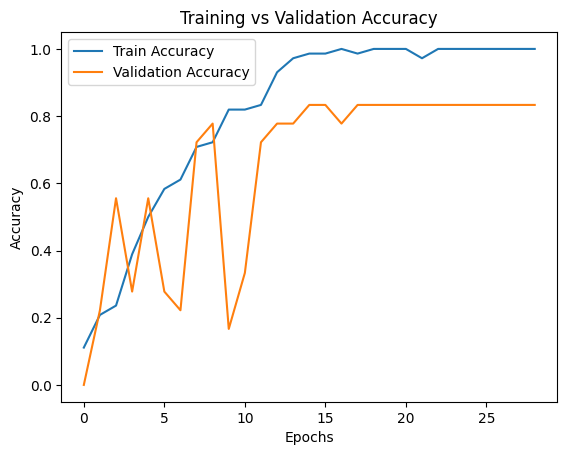

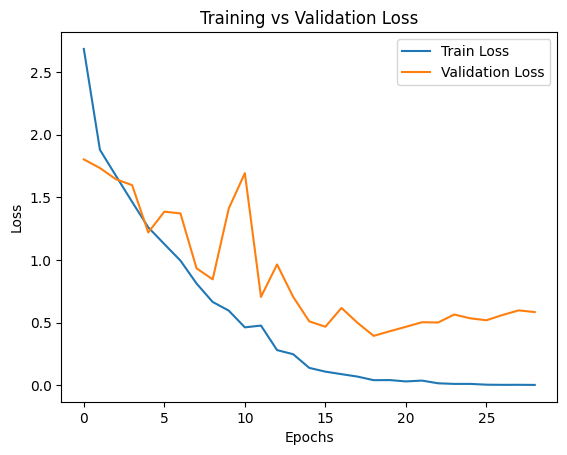

In [34]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')

plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')

plt.show()

In [26]:
model.save("final_model.h5")

In [28]:
import tensorflow as tf

loaded_model = tf.keras.models.load_model('final_model.h5')
loss, acc = loaded_model.evaluate(test_ds)

print("Loaded Model Accuracy:", acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.6000 - loss: 1.0958
Loaded Model Accuracy: 0.6000000238418579


In [29]:
import numpy as np

y_pred = []
y_true = []

for images, labels in test_ds:
    preds = model.predict(images)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 343ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step


In [31]:
from sklearn.metrics import classification_report

class_names = classes

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.67      0.80      0.73         5
      tucuma       0.40      0.40      0.40         5
     pupunha       0.56      1.00      0.71         5
     cupuacu       0.60      0.60      0.60         5
     guarana       1.00      0.40      0.57         5
    graviola       0.67      0.40      0.50         5

    accuracy                           0.60        30
   macro avg       0.65      0.60      0.59        30
weighted avg       0.65      0.60      0.59        30

